In [2]:
#Import libraries
import pandas as pd

#Load the dataset
phish = pd.read_csv("/Users/mouyly/Downloads/2malware/kaggle_spam.csv")

#Display basic info
print("Dataset shape:", phish.shape)
print("\nColumn names:\n", phish.columns.tolist())
phish.head()


Dataset shape: (5572, 5)

Column names:
 ['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
# keep usful column and rename
sms = phish[['v1', 'v2']].copy()
sms.columns = ['label', 'text']   # v1 -> label, v2 -> text

print("After select/rename:", sms.shape)
display(sms.head())
display(sms.dtypes)


After select/rename: (5572, 2)


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


label    object
text     object
dtype: object

In [4]:
#check for duplicate and missing
print("Duplicate rows:", sms.duplicated().sum())
print("\nMissing values per column:")
print(sms.isna().sum())


Duplicate rows: 414

Missing values per column:
label    0
text     0
dtype: int64


In [5]:
# drop duplicates and clean text
before = sms.shape[0]
sms = sms.drop_duplicates()
after = sms.shape[0]
print(f"Removed {before - after} duplicate rows. New shape: {sms.shape}")


Removed 414 duplicate rows. New shape: (5158, 2)


In [7]:
# clean the SMS text column (simple + safe)

sms['text'] = (
    sms['text']
    .fillna('')
    .astype(str)
    .str.lower()
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

print("text cleaned")
display(sms.head())


text cleaned


,label,text
0,ham,"go until jurong point, crazy.. available only ..."
1,ham,ok lar... joking wif u oni...
2,spam,free entry in 2 a wkly comp to win fa cup fina...
3,ham,u dun say so early hor... u c already then say...
4,ham,"nah i don't think he goes to usf, he lives aro..."


Unique labels: ['ham' 'spam']
Numeric mapping check:
 label_num
0    4516
1     642
Name: count, dtype: int64


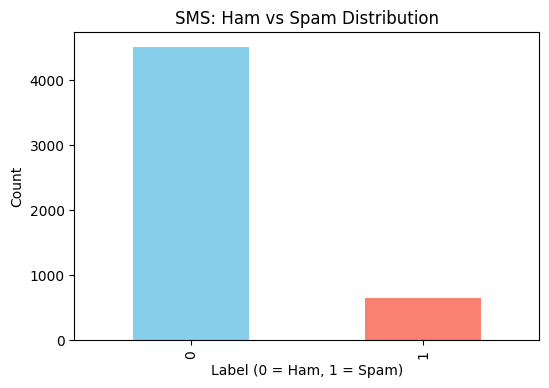

In [8]:
#Map labels to numeric values and visualize balance
import matplotlib.pyplot as plt

# map ham→0, spam→1
sms["label_num"] = sms["label"].map({"ham": 0, "spam": 1})

# check for unexpected labels
print("Unique labels:", sms["label"].unique())
print("Numeric mapping check:\n", sms["label_num"].value_counts())

# visualize
plt.figure(figsize=(6,4))
sms["label_num"].value_counts().sort_index().plot(
    kind="bar",
    color=["skyblue","salmon"],
    title="SMS: Ham vs Spam Distribution"
)
plt.xlabel("Label (0 = Ham, 1 = Spam)")
plt.ylabel("Count")
plt.show()


In [9]:
from sklearn.model_selection import train_test_split

# Separate features and labels
X = sms[['text']].copy()
y = sms['label_num'].copy()

#80% train, 20% temp
X_train_s, X_temp_s, y_train_s, y_temp_s = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#split the 20% temp into 10% validation, 10% test
X_valid_s, X_test_s, y_valid_s, y_test_s = train_test_split(
    X_temp_s, y_temp_s, test_size=0.5, random_state=42, stratify=y_temp_s
)

# Display results
print("Train:", X_train_s.shape, y_train_s.shape)
print("Valid:", X_valid_s.shape, y_valid_s.shape)
print("Test :", X_test_s.shape,  y_test_s.shape)


Train: (4126, 1) (4126,)
Valid: (516, 1) (516,)
Test : (516, 1) (516,)


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF with top 5000 features and English stopwords
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

# Fit only on training data and transform all splits
X_train_tfidf = tfidf.fit_transform(X_train_s['text'])
X_valid_tfidf = tfidf.transform(X_valid_s['text'])
X_test_tfidf  = tfidf.transform(X_test_s['text'])

print("TF-IDF transformation complete!")
print("Train shape:", X_train_tfidf.shape)
print("Validation shape:", X_valid_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)


TF-IDF transformation complete!
Train shape: (4126, 5000)
Validation shape: (516, 5000)
Test shape: (516, 5000)


In [11]:
# Save all splits
X_train_s.to_csv("sms_X_train.csv", index=False)
y_train_s.to_csv("sms_y_train.csv", index=False)

X_valid_s.to_csv("sms_X_valid.csv", index=False)
y_valid_s.to_csv("sms_y_valid.csv", index=False)

X_test_s.to_csv("sms_X_test.csv", index=False)
y_test_s.to_csv("sms_y_test.csv", index=False)

print("All SMS dataset splits saved successfully!")


All SMS dataset splits saved successfully!
